In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
np.random.seed(42)

n_samples = 500

data = pd.DataFrame({
    "processing_power": np.random.randint(1, 100, n_samples),
    "energy_efficiency": np.random.randint(1, 100, n_samples),
    "cost": np.random.randint(1000, 10000, n_samples),
    "durability": np.random.randint(1, 100, n_samples),
    "user_rating": np.random.uniform(1, 5, n_samples)
})

# Create a target variable (classification)
# 1 = successful technology, 0 = unsuccessful
data["success"] = (
    (data["processing_power"] * 0.3 +
     data["energy_efficiency"] * 0.3 +
     data["durability"] * 0.2 +
     data["user_rating"] * 10 -
     data["cost"] * 0.0005) > 50
).astype(int)

# Save dataset
data.to_csv("ImaginaryTechnology.csv", index=False)

data.head()

,processing_power,energy_efficiency,cost,durability,user_rating,success
0,52,51,2761,50,1.413236,1
1,93,86,1876,82,3.338683,1
2,15,57,4812,62,3.752831,1
3,72,29,2460,17,2.589516,1
4,61,78,2733,88,2.919588,1


In [3]:
df = pd.read_csv("ImaginaryTechnology.csv")

X = df.drop("success", axis=1)
y = df["success"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_preds))
print(classification_report(y_test, dt_preds))

Decision Tree Accuracy: 0.85
              precision    recall  f1-score   support

           0       0.61      0.70      0.65        20
           1       0.92      0.89      0.90        80

    accuracy                           0.85       100
   macro avg       0.77      0.79      0.78       100
weighted avg       0.86      0.85      0.85       100



In [6]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.92
              precision    recall  f1-score   support

           0       0.93      0.65      0.76        20
           1       0.92      0.99      0.95        80

    accuracy                           0.92       100
   macro avg       0.92      0.82      0.86       100
weighted avg       0.92      0.92      0.91       100



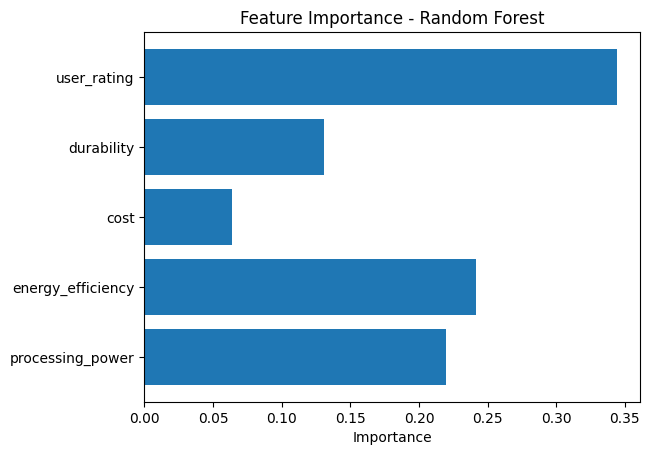

In [7]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance - Random Forest")
plt.show()